In [16]:
import os, sys, glob, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from scipy.stats import ttest_ind

REPO = '/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
import eigen_steering
from eigen_steering import EigenMap, MPRAHead, AlphaGenomeMPRA

# Local layout: weights at pytorch_base_model/, ckpts at models/{name}/best_stage2.pt
eigen_steering.WEIGHTS_PATH = os.path.join(REPO, 'pytorch_base_model', 'model_fold_0.safetensors')
CKPT_DIR = os.path.join(REPO, 'models')

CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- libraries: sequences + precomputed attributions ---
df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

em = EigenMap(model_names=CT, device=DEVICE)
em.load_from_dataframe(df, seq_col='sequence')
em.set_actual({ct: df[f'{ct}_log2FC'].values for ct in CT})

raw = np.load(os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'))
df_full = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
seq_valid = df_full['sequence'].notna(); n = seq_valid.sum()
keep = df_full.loc[seq_valid, ['sequence'] + [f'{ct}_log2FC' for ct in CT]].notna().all(axis=1).values
del df_full

ohe = em.X.numpy()
for ct in CT:
    hyp = raw[f'attr_{ct}'][:n][keep]
    em.attr_hyp[ct] = hyp; em.attr[ct] = hyp * ohe
    em.importance[ct] = em.attr[ct].sum(axis=1)
    em.predictions[ct] = raw[f'predictions_{ct}'][:n][keep]

# --- eigen cache + focused library ---
with open(os.path.join(REPO, 'genomic_targets', 'data', 'eigen_analysis.pkl'), 'rb') as f:
    cached = pickle.load(f)
ei1_var = cached['ei1_var']; corrs = cached['corrs']; eixr = ei1_var * corrs

with open(os.path.join(REPO, 'virtual_perturbations/libraries/hippo_target_library.pkl'), 'rb') as f:
    target_lib = pickle.load(f)
focus_idx = target_lib['df']['seq_idx'].values

# --- per-replicate MPRA stats ---
MPRA_DIR = os.path.join(REPO, 'data', 'full_joint_mpra')
COLS = ['cell', 'rep', 'name', 'dna', 'rna', 'ratio', 'log2_ratio', 'n_bc']
def _load(cell):
    return pd.concat([pd.read_csv(f, sep='\t', header=None, names=COLS)
                      for f in sorted(glob.glob(f'{MPRA_DIR}/{cell}/{cell}_rep*.tsv'))],
                     ignore_index=True)
hep_w = _load('HepG2').pivot_table(index='name', columns='rep', values='log2_ratio')
k_w   = _load('K562' ).pivot_table(index='name', columns='rep', values='log2_ratio')
shared = hep_w.index.intersection(k_w.index)
H, K = hep_w.loc[shared].values, k_w.loc[shared].values
ok = np.isfinite(H).all(1) & np.isfinite(K).all(1)
_, pv = ttest_ind(H[ok], K[ok], axis=1, equal_var=False)
diffs = df['name'].map(dict(zip(shared[ok], H[ok].mean(1) - K[ok].mean(1)))).values.astype(float)
pvals = df['name'].map(dict(zip(shared[ok], pv))).values.astype(float)

# --- heavy load: models on GPU (ckpts live at models/{name}/best_stage2.pt) ---
def _load_model_patched(self, ct, squeeze=False):
    eigen_steering._load_heavy_deps()
    name = self.model_names[ct]
    ckpt_path = os.path.join(CKPT_DIR, name, 'best_stage2.pt')
    print(f"  Loading {ct}: {ckpt_path}")
    enc = eigen_steering.AlphaGenome.from_pretrained(eigen_steering.WEIGHTS_PATH, device='cpu')
    eigen_steering.remove_all_heads(enc)
    hd = MPRAHead()
    ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    enc.load_state_dict(ckpt['model_state_dict'], strict=False)
    hd.load_state_dict(ckpt['head_state_dict'])
    return AlphaGenomeMPRA(enc, hd, squeeze=squeeze).to(self.device).eval()

EigenMap._load_model = _load_model_patched
models = em._load_models()

print(f'\n{len(df)} seqs on {DEVICE} | EIxr n={len(eixr)} | focus={len(focus_idx)} | mpra={np.isfinite(diffs).sum()}')
for ct, m in models.items():
    print(f'  {ct}: {sum(p.numel() for p in m.parameters())/1e6:.2f}M params on {next(m.parameters()).device}')

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
Loaded 56975 sequences, X shape: torch.Size([56975, 4, 281])
  Loading K562: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/best_stage2.pt
  Loading HepG2: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/best_stage2.pt

56975 seqs on cuda | EIxr n=56975 | focus=1059 | mpra=56962
  K562: 408.64M params on cuda:0
  HepG2: 408.64M params on cuda:0


condition
same-diff    353
diff-diff    353
same-same    353
Name: count, dtype: int64
{'same-same': 53997, 'diff-diff': 26012, 'same-diff': 56772}


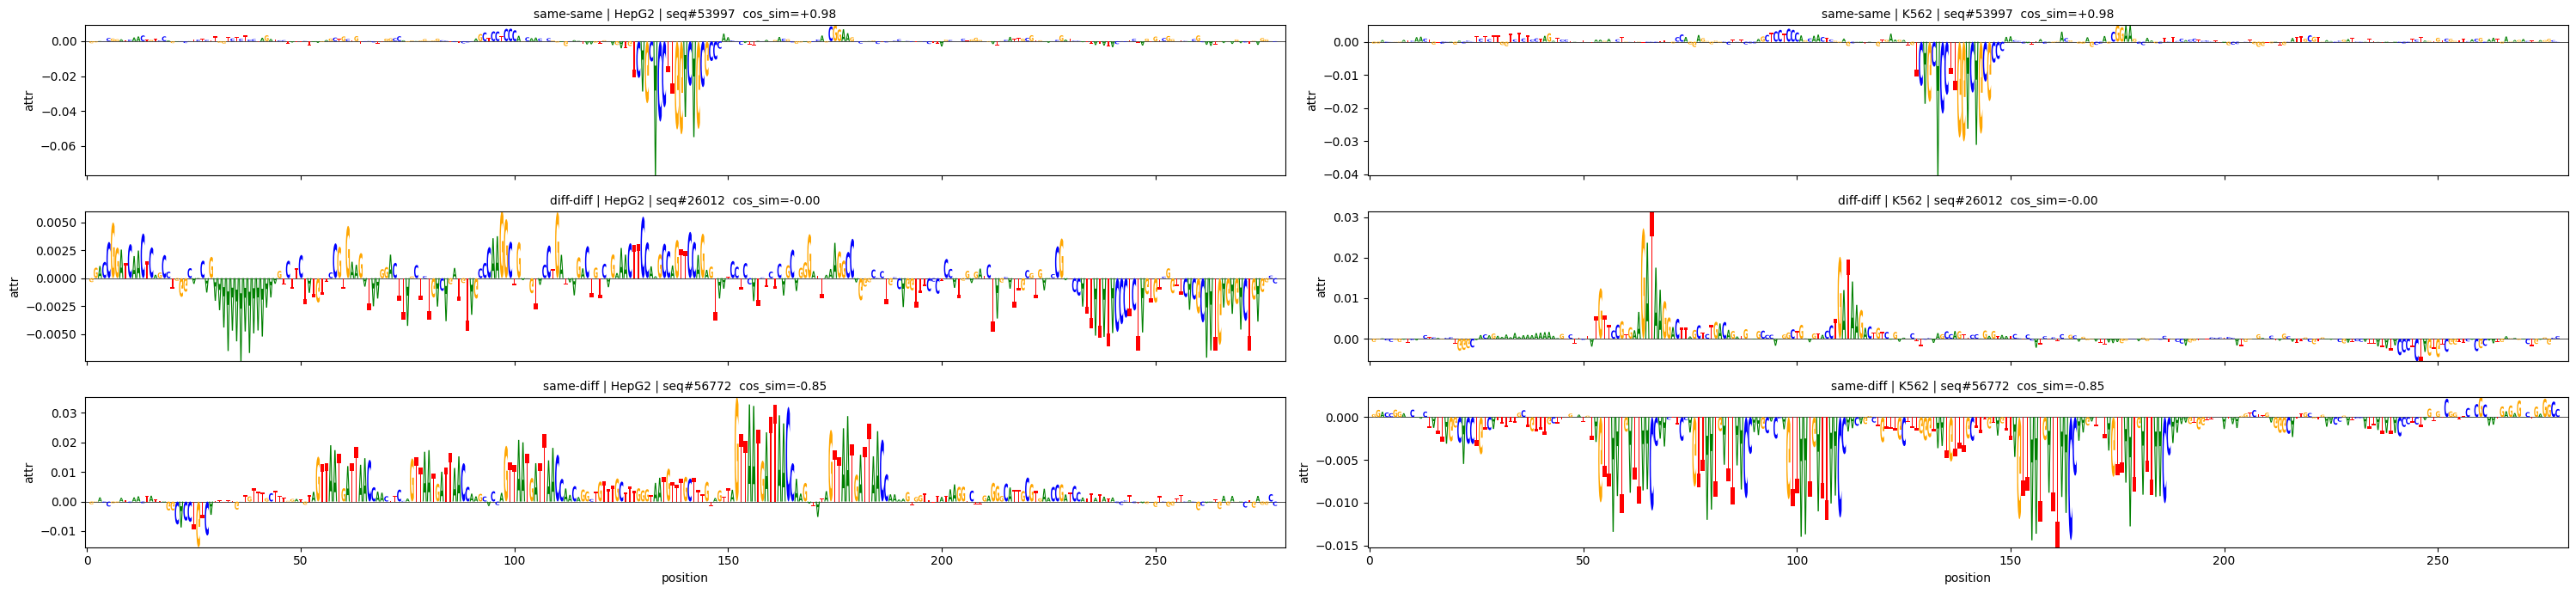

In [17]:
import logomaker as lm

lib = target_lib['df']
print(lib['condition'].value_counts())

reps = {cond: int(lib[lib['condition'] == cond].iloc[0]['seq_idx'])
        for cond in ['same-same', 'diff-diff', 'same-diff']}
print(reps)

# enhancer-only (1x230) cosine sim over per-position importance (== EI corrs)
cs_all = em.cosine_similarity(enhancer_only=True, mode='importance', zscore=True)  # (N,)

fig, axes = plt.subplots(3, 2, figsize=(30, 7), sharex=True)
for r, (name, i) in enumerate(reps.items()):
    for c, ct in enumerate(['HepG2', 'K562']):
        att = em.attr[ct][i].T  # (281, 4)
        lm.Logo(pd.DataFrame(att, columns=list('ACGT')), ax=axes[r, c])
        axes[r, c].set_title(f'{name} | {ct} | seq#{i}  cos_sim={cs_all[i]:+.2f}', fontsize=10)
        axes[r, c].set_ylabel('attr')
axes[-1, 0].set_xlabel('position'); axes[-1, 1].set_xlabel('position')
plt.tight_layout(); plt.show()

EigenMap: ['K562', 'HepG2'], models={'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
DeepLIFT/SHAP: K562...
  Loading K562: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/K562_v6_do075/best_stage2.pt


  0%|          | 0/3150 [00:00<?, ?it/s]/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.1311, 0.0627, 0.0470, 0.0561, 0.0838, 0.2562, 0.0651, 0.0115, 0.2245,
        0.0413, 0.1375, 0.0477, 0.1116, 0.1155, 0.1018, 0.1780, 0.3773, 0.1684,
        0.0715, 0.0242, 0.1804, 0.2478, 0.2128, 0.2108, 0.0893, 0.0556, 0.0701,
        0.0845, 0.2000, 0.4203, 0.0882, 0.0872, 0.0119, 0.1232, 0.2638, 0.0143,
        0.1699, 0.0791, 0.2556, 0.2963, 0.0899, 0.0450, 0.2751, 0.1431, 0.0072,
        0.1459, 0.1962, 0.3339, 0.0288, 0.1672, 0.2499, 0.1172, 0.3367, 0.0078,
        0.2598, 0.1809, 0.2227, 0.1258, 0.2026, 0.4662, 0.0929, 0.0134, 0.0833,
        0.1588, 0.3284, 0.0182, 0.2070, 0.3273, 0.0135, 0.1992, 0.2370, 0.2125,
        0.2344, 0.0550, 0.1683, 0.2727, 0.3498, 0.0850, 0.4235, 0.3081, 0.0291,
        0.0371, 0.1195, 0.0517

DeepLIFT/SHAP: HepG2...
  Loading HepG2: /grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/models/HepG2_v6_do03/best_stage2.pt


  0%|          | 0/3150 [00:00<?, ?it/s]/grid/koo/home/pmantill/projects/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/Hippo_agft_venv/lib/python3.12/site-packages/tangermeme/deep_lift_shap.py:465: RuntimeWarning: Convergence deltas too high: tensor([0.0506, 0.1336, 0.3208, 0.4338, 0.0679, 0.3299, 0.1726, 0.2914, 0.3277,
        0.0083, 0.3970, 0.2398, 0.1099, 0.1191, 0.3555, 0.5100, 0.0887, 0.4790,
        0.3634, 0.0412, 0.0298, 0.4668, 0.0634, 0.2425, 0.2997, 0.0848, 0.4455,
        0.3335, 0.2388, 0.2438, 0.3869, 0.1974, 0.0096, 0.4196, 1.0218, 0.7317,
        0.3328, 0.2617, 0.4383, 0.0869, 0.1870, 0.3088, 0.0550, 0.0240, 0.6027,
        0.3919, 0.5629, 0.1159, 0.0221, 0.0961, 0.5068, 0.5047, 0.0397, 0.4958,
        0.0409, 0.2825, 0.3530, 0.0425, 0.0991, 0.5852, 0.2065, 0.2357, 0.0597,
        0.5044, 0.3192, 0.5441, 0.6109, 0.3530, 0.0026, 0.2795, 0.2137, 0.4498,
        0.3054, 0.6065, 0.3882, 0.5280, 0.1608, 0.3217, 0.3757, 0.0685, 0.0529,
        0.2646, 0.5852, 0.2134

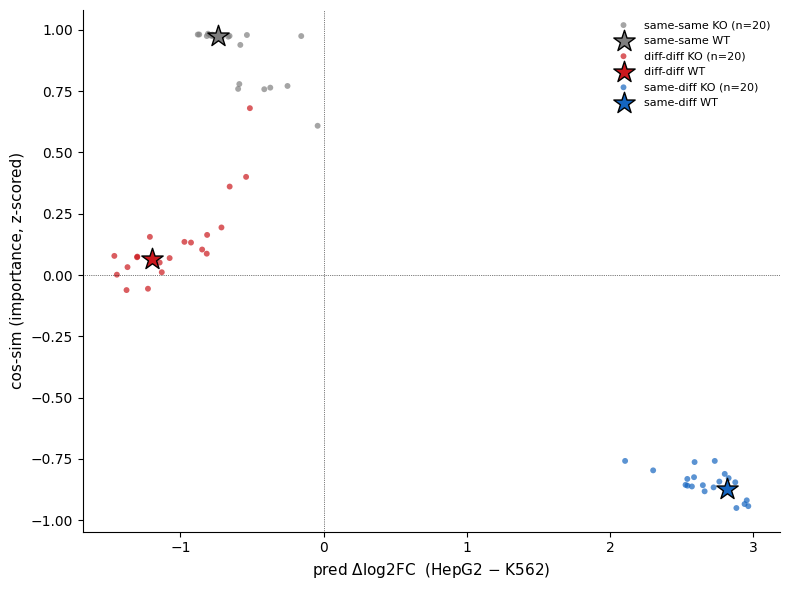

In [21]:
# --- knobs ---
N_REPS  = 20    # KO variants per seq
WIN     = 30    # contiguous KO window (bp), within enhancer
# -------------

# Random contiguous KOs the EigenMap-native way (like necessity_test,
# but at random windows instead of motif positions):
#   1. dinucleotide-shuffle the WHOLE WT seq -> background
#   2. for each variant, replace WT[s:s+W] with shuffle[s:s+W]
# Plot pred Δlog2FC vs cos-sim (importance, z-scored), WT marked.

eigen_steering._load_heavy_deps()
dinuc_shuf = eigen_steering.dinucleotide_shuffle

rng     = np.random.default_rng(0)
ENH_LEN = eigen_steering.ENHANCER_LEN  # 230
L       = em.X.shape[-1]               # 281

groups = list(reps.items())   # [('same-same', i), ('diff-diff', j), ('same-diff', k)]
all_X, tag = [], []
wt_pos = {}
for name, idx in groups:
    wt   = em.X[idx:idx+1].float()                                      # (1,4,L)
    shuf = dinuc_shuf(wt, n=N_REPS, random_state=int(idx))[0]           # (N_REPS,4,L)
    wt_pos[name] = sum(t.shape[0] for t in all_X)
    all_X.append(wt); tag.append(('WT', name))

    chim = wt.expand(N_REPS, -1, -1).clone()                            # (N_REPS,4,L)
    for k in range(N_REPS):
        s = int(rng.integers(0, ENH_LEN - WIN + 1))
        chim[k, :, s:s+WIN] = shuf[k, :, s:s+WIN]
    all_X.append(chim); tag += [('var', name)] * N_REPS

X = torch.cat(all_X, dim=0)   # (3 + 3*N_REPS, 4, L)

em_s = EigenMap(model_names=CT, device=DEVICE)
em_s.X         = X
em_s.constructs = [''] * X.shape[0]
em_s.enhancers  = [''] * X.shape[0]
em_s.compute_attributions(method='deeplift', n_shuffles=50, batch_size=128, verbose=True)

cs    = em_s.cosine_similarity(enhancer_only=True, mode='importance', zscore=True)
mdiff = em_s.predictions['HepG2'] - em_s.predictions['K562']

colors = {'same-same': '#7f7f7f', 'diff-diff': '#cb181d', 'same-diff': '#1565C0'}

fig, ax = plt.subplots(figsize=(8, 6))
for name, _ in groups:
    m = np.array([t == ('var', name) for t in tag])
    ax.scatter(mdiff[m], cs[m], s=18, c=colors[name],
               alpha=0.7, edgecolors='none', label=f'{name} KO (n={m.sum()})')
    w = wt_pos[name]
    ax.scatter([mdiff[w]], [cs[w]], s=260, c=colors[name],
               marker='*', edgecolors='black', linewidths=1.0,
               label=f'{name} WT', zorder=5)
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.axvline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('pred $\\Delta$log2FC  (HepG2 $-$ K562)', fontsize=11)
ax.set_ylabel('cos-sim (importance, z-scored)', fontsize=11)
ax.legend(fontsize=8, frameon=False)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()